# Exercise 5: Unicycle Optimal Control

Consider the kinematic model of a unicycle:
\begin{equation}
\dot{x} = v \cos(\theta), \quad \dot{y} = v \sin(\theta), \quad \dot{\theta} = \omega.
\end{equation}
where $(x,y)$ is the position, $\theta$ is the heading angle with respect to the x-axis, and the control inputs are the speed $v$ and the angular velocity $\omega$. We define the state vector $\textbf{x} = (x, y, \theta)$.

In this problem we will compute the optimal control to drive the unicycle vehicle from a starting configuration $\textbf{x}(0) = (0, 0, \pi/2)$ to the target configuration $\textbf{x}(T) = (5, 5, \pi/2)$. We seek to find a solution that minimizes time to the target configuration while also minimizing the control effort required. Specifically, we want to minimize:
\begin{equation}
J(x,u) = \int_0^T  \alpha + v(t)^2 + \omega(t)^2  dt,
\end{equation}
where $\alpha > 0$ is a constant weighting factor and $T$ is the free final time.

### Exercise 5.2: Define the dynamics, Hamiltonian, and necessary optimality conditions

NOTE: It can be good to use both `jax.numpy` and regular `numpy`, as `numpy` operations are typically much faster than their `jax.numpy` counterparts (at least before `jax.jit`) whenever JAX-specific magic (e.g., automatic differentiation, vectorization) is not required. However, since in this exercise we encourage you to use `jax.numpy` for practice.

In [1]:
import jax
import jax.numpy as jnp
from jax.experimental.ode import odeint
import matplotlib.pyplot as plt

First, implement the function `unicycle_dynamics`:

In [2]:
def unicycle_dynamics(x: jnp.array, u: jnp.array) -> jnp.array:
    """
    Evaluate the continuous-time dynamics of a unicycle.

    Args:
        x: an array of shape (3,) containing the unicycle pose (x, y, θ).
        u: an array of shape (2,) containing the velocity controls (v, ω).

    Returns:
        An array of shape (3,) containing the time derivative of the state (dx/dt, dy/dt, dθ/dt)
    """
    ##### YOUR CODE STARTS HERE #####
    dx_dt = u[0] * jnp.cos(x[2])
    dy_dt = u[0] * jnp.sin(x[2])
    dtheta_dt = u[1]
    return jnp.array([dx_dt, dy_dt, dtheta_dt])
    ###### YOUR CODE ENDS HERE ######

Next, derive the Hamiltonian for the optimal control problem and implement the function `hamiltonian` below to compute it:

In [3]:
def hamiltonian(x: jnp.array, p: jnp.array, u: jnp.array) -> float:
    """
    Evaluate the Hamiltonian.

    Args:
        x: an array of shape (3,) containing the unicycle pose (x, y, θ).
        p: an array of shape (3,) containing the co-state (px, py, pθ).
        u: an array of shape (2,) containing the velocity controls (v, ω).

    Returns:
        The value of the Hamiltonian.
    """
    α = 0.25
    ##### YOUR CODE STARTS HERE #####
    H = α + u[0]**2 + u[1]**2 + jnp.dot(p, unicycle_dynamics(x, u))
    return H
    ###### YOUR CODE ENDS HERE ######

From the Hamiltonian, we can now derive the optimal control function $u^*(t)$ and the set of ordinary differential equations and their boundary conditions that constitute the necessary optimality conditions. Implement the function $u^*(t)$ in `optimal_control` and the ordinary differential equations for the NOCs in `noc_ode`.

In [4]:
def optimal_control(x: jnp.array, p: jnp.array) -> jnp.array:
    """
    Compute an optimal control as a function of the state and co-state.

    Args:
        x: an array of shape (3,) containing the unicycle pose (x, y, θ).
        p: an array of shape (3,) containing the co-state (px, py, pθ).

    Returns:
        An array of shape (2,) containing an optimal control u* = (v*, ω*).
    """
    ##### YOUR CODE STARTS HERE #####
    v_star = -0.5 * (p[0] * jnp.cos(x[2]) + p[1] * jnp.sin(x[2]))
    omega_star = -0.5 * p[2]
    return jnp.array([v_star, omega_star])
    ###### YOUR CODE ENDS HERE ######

In [5]:
def noc_ode(x_and_p: tuple[jnp.array, jnp.array],
            t: float) -> tuple[jnp.array, jnp.array]:
    """
    Evaluate the ODE that an optimal state and co-state must obey.

    Args:
        x_and_p: a tuple of arrays (x, p), where x is an array of shape
                 (3,) containing the unicycle pose (x, y, θ), and p is
                 an array of shape (3,) containing the co-state (px, py, pθ).
        t: the current time (required for use with `odeint`, but can be ignored here).

    Returns:
        A tuple of arrays (dx/dt, dp/dt) containing the time derivatives of the
        state and co-state, respectively.
    """
    x, p = x_and_p
    ##### YOUR CODE STARTS HERE #####
    u_star = optimal_control(x, p)
    dx_dt = unicycle_dynamics(x, u_star)
    dp_dt = -jax.grad(hamiltonian, argnums=0)(x, p, u_star)
    return dx_dt, dp_dt
    ###### YOUR CODE ENDS HERE ######

### Exercise 5.3: Define the boundary condition residual function
Now, use the `noc_trajectories` function defined below to complete the code for `boundary_residual`, where we want to compute the residual error of the boundary conditions for the NOCs. In other words, we want to express the boundary conditions in a standard form $l(z(t_0), z(t_f)) = 0$ where $z$ represents a vector of the states and costates and have `boundary_residual` return $l(z(t_0), z(t_f))$.

In [6]:
def noc_trajectories(x0: jnp.array,
                     p0: jnp.array,
                     T: float,
                     N: int = 20) -> tuple[jnp.array, jnp.array, jnp.array,
                                           jnp.array]:
    """
    Integrate the optimal state and co-state ODE forward in time.

    Args:
        x0: an array of shape (3,) containing the initial state (x(0), y(0), θ(0)).
        p0: an array of shape (3,) containing the initial co-state (px(0), py(0), pθ(0)).
        T: the final time T.
        N: the number of nodes along the ODE solution at which to report the
           solution values.

    Returns:
        A tuple of arrays (ts, xs, us, ps) where:
            ts: an array of shape (N,) containing a sequence of times
                 spanning [0, T].
            xs: an array of shape (N, 3) containing the states at ts.
            us: an array of shape (N, 2) containing the optimal control
                 inputs at ts.
            ps: an array of shape (N, 3) containing the co-states at ts.
    """
    ts = jnp.linspace(0, T, N)
    xs, ps = odeint(noc_ode, (x0, p0), ts)
    us = jax.vmap(optimal_control)(xs, ps)
    return ts, xs, us, ps

def boundary_residual(p0: jnp.array,
                      T: float,
                      x0: jnp.array,
                      xT: jnp.array) -> jnp.array:
    """
    Compute the residual error of the boundary conditions for the NOCs.

    Args:
        p0: an array of shape (3,) containing the initial co-state (px(0), py(0), pθ(0)) 
             estimate.
        T:  the final time T estimate.
        x0: an array of shape (3,) containing the initial state (x(0), y(0), θ(0)).
        xT: an array of shape (3,) containing the final state x(T), y(T), θ(T)).

    Returns:
        The array of shape (4,) we want to drive to zero through appropriate
        selection of p0 and T.
    """
    ##### YOUR CODE STARTS HERE #####
    # Hint: Use `noc_trajectories` here to compute xs, ps
    # xT, pT = xs[-1], ps[-1]
    ts, xs, us, ps = noc_trajectories(x0, p0, T)
    xT_actual, uT_actual, pT_actual = xs[-1], us[-1], ps[-1]
    state_error = xT_actual - xT
    hT = hamiltonian(xT_actual, pT_actual, uT_actual)
    return jnp.concatenate([state_error, jnp.array([hT])])
    ###### YOUR CODE ENDS HERE ######

Now that we have implemented `boundary_residual` our goal is to find a way to get the boundary conditions to be satisfied, or in other words have `boundary_residual` return a zero vector. To do this, we need a method to search over a set of initial costate values and the final time $T$ to find a solution with zero residual. We will use a Newton-Raphson method to accomplish this. Implement the Newton-Raphson step in the function `newton_step` below.

In [7]:
# Uncomment `@jax.jit` for a speedier runtime per iteration (post-compilation),
# but a harder time debugging.
@jax.jit
def newton_step(p0: jnp.array,
                T: float,
                x0: jnp.array,
                xT: jnp.array) -> tuple[jnp.array, float]:
    """
    Implement a step of the Newton-Raphson method for `boundary_residual`.

    Args:
        p0: an array of shape (3,) containing the current initial co-state
             (px(0), py(0), pθ(0)) estimate.
        T: the current final time T estimate.
        x0: an array of shape (3,) containing the initial state (x(0), y(0), θ(0)).
        xT: an array of shape (3,) containing the final state (x(T), y(T), θ(T)).

    Returns:
        A tuple containing the next estimate of p0 and T computed by the
        Newton-Raphson method.
    """
    ##### YOUR CODE STARTS HERE #####
    # Hint: Use `jax.jacobian` and `jnp.linalg.solve`.
    residual = boundary_residual(p0, T, x0, xT)
    jacobian_p, jacobian_T = jax.jacobian(boundary_residual, argnums=(0, 1))(p0, T, x0, xT)
    jacobian = jnp.hstack([jacobian_p, jacobian_T.reshape(-1, 1)])
    delta = jnp.linalg.solve(jacobian, -residual)
    p0 = p0 + 0.5 *delta[:3]
    T = T + 0.5 * delta[3]
    ###### YOUR CODE ENDS HERE ######
    return p0, T

Now, run the code below to run iterations of the Newton-Raphson method to find the initial costate parameters and the final time that will satisfy the necessary optimality conditions, and thus will give us the optimal control for the unicycle problem.

Iteration 0 (error = 0.6416082382202148)
Iteration 1 (error = 0.43144702911376953)
Iteration 2 (error = 0.22234535217285156)
Iteration 3 (error = 0.1109156608581543)
Iteration 4 (error = 0.05533027648925781)
Iteration 5 (error = 0.02752399444580078)
Iteration 6 (error = 0.013742923736572266)
Iteration 7 (error = 0.006900787353515625)
Iteration 8 (error = 0.003509044647216797)
Iteration 9 (error = 0.001682281494140625)
Iteration 10 (error = 0.000823974609375)
Iteration 11 (error = 0.0003800392150878906)
Iteration 12 (error = 0.0002994537353515625)
Iteration 13 (error = 0.00012922286987304688)
Iteration 14 (error = 0.00010967254638671875)
Iteration 15 (error = 3.075599670410156e-05)


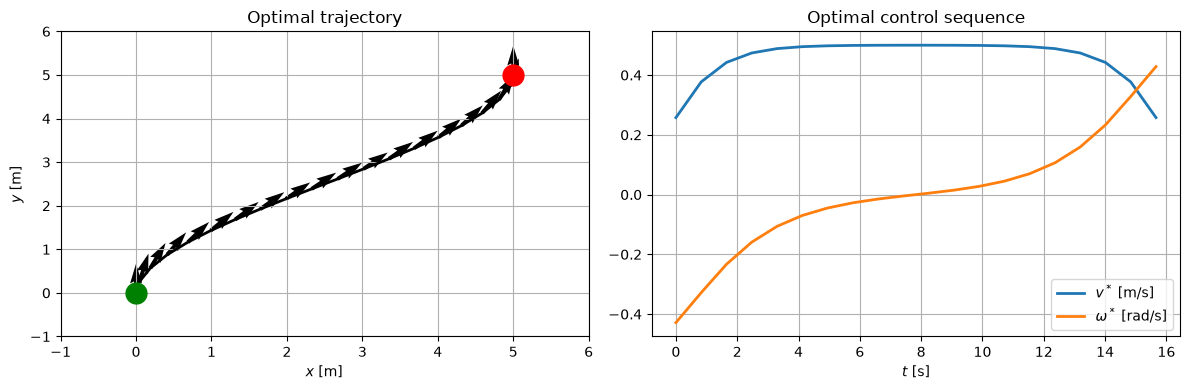

In [8]:
def single_shooting(p0: jnp.array,
                    T: float,
                    x0: jnp.array,
                    xT: jnp.array,
                    max_iters: int = 30,
                    tol: float = 1e-4) -> tuple[jnp.array, float]:
    """
    Single shooting for the unicycle using a Newton-Raphson root finding method.

    Args:
        p0: an array of shape (3,) containing an initial guess for the
            initial co-state (px(0), py(0), pθ(0)).
        T: an initial guess for the final time T.
        x0: an array of shape (3,) containing the initial state (x(0), y(0), θ(0)).
        xT: an array of shape (3,) containing the desired final state (x(T), y(T), θ(T)).
        max_iters: the maximum number of Newton-Raphson steps to take.
        tol: the convergence tolerance.

    Returns:
        A tuple containing the optimized initial co-state p0 and final time T.
    """
    converged = False
    for k in range(max_iters):
        p0, T = newton_step(p0, T, x0, xT)
        r = boundary_residual(p0, T, x0, xT)
        error = jnp.max(jnp.abs(r))
        print('Iteration {} (error = {})'.format(k, error))
        if error < tol:
            converged = True
            break
    if not converged:
        raise RuntimeError('Single shooting did not converge!')
    return p0, T


p0_init = jnp.array([-0.5, -0.5, 0.5])
T_init = 20.

x0 = jnp.array([0, 0, jnp.pi / 2])
xT = jnp.array([5, 5, jnp.pi / 2])
p0, T = single_shooting(p0_init, T_init, x0, xT)
ts, xs, us, ps = noc_trajectories(x0, p0, T)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(xs[:, 0], xs[:, 1], 'k-', linewidth=2)
ax[0].quiver(xs[:, 0], xs[:, 1], jnp.cos(xs[:, 2]), jnp.sin(xs[:, 2]))
ax[0].plot(x0[0], x0[1], 'go', markerfacecolor='green', markersize=15)
ax[0].plot(xT[0], xT[1], 'ro', markerfacecolor='red', markersize=15)
ax[0].grid(True)
ax[0].axis([-1, 6, -1, 6])
ax[0].set_xlabel(r'$x$ [m]')
ax[0].set_ylabel(r'$y$ [m]')
ax[0].set_title('Optimal trajectory')

ax[1].plot(ts, us[:, 0], linewidth=2)
ax[1].plot(ts, us[:, 1], linewidth=2)
ax[1].grid(True)
ax[1].set_xlabel(r'$t$ [s]')
ax[1].legend([r'$v^*$ [m/s]', r'$\omega^*$ [rad/s]'])
ax[1].set_title('Optimal control sequence')

plt.tight_layout()
plt.show()